# 3. Özellik Mühendisliği

Bu notebook'ta meteorolojik verilerden özellikler çıkaracak ve modele hazır veri seti oluşturacağız.

**İçerik:**
- Meteorolojik özelliklerin eklenmesi
- Lag (gecikme) özellikleri
- Rolling window istatistikleri
- Türetilmiş özellikler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print('Kütüphaneler yüklendi!')

Kütüphaneler yüklendi!


## 3.1 Verilerin Yüklenmesi

In [2]:
DATA_PATH = '../data/'

ana_df = pd.read_pickle(DATA_PATH + 'ana_veri_seti.pkl')
istasyonlar = pd.read_pickle(DATA_PATH + 'istasyonlar.pkl')

print(f"Ana veri seti: {ana_df.shape}")
print(f"\nSütunlar: {ana_df.columns.tolist()}")

Ana veri seti: (23622, 14)

Sütunlar: ['tarih', 'istasyon_no', 'yildirim_sayisi', 'ort_akim', 'maks_akim', 'min_akim', 'ort_mesafe', 'yildirim_var', 'yil', 'ay', 'gun', 'haftanin_gunu', 'yilin_gunu', 'mevsim']


## 3.2 İstasyon Bilgilerinin Eklenmesi

In [3]:
# İstasyon bilgilerini ekle
ana_df = ana_df.merge(
    istasyonlar[['istasyon_no', 'enlem', 'boylam', 'rakim']],
    on='istasyon_no',
    how='left'
)

print("İstasyon bilgileri eklendi!")
display(ana_df.head())

İstasyon bilgileri eklendi!


,tarih,istasyon_no,yildirim_sayisi,ort_akim,maks_akim,min_akim,ort_mesafe,yildirim_var,yil,ay,gun,haftanin_gunu,yilin_gunu,mevsim,enlem,boylam,rakim
0,2015-02-06,17285,0,NaN,NaN,NaN,NaN,0,2015,2,6,4,37,0,37.5745,43.7388,1727
1,2015-02-06,17920,0,NaN,NaN,NaN,NaN,0,2015,2,6,4,37,0,37.5785,44.2862,1877
2,2015-02-06,18234,0,NaN,NaN,NaN,NaN,0,2015,2,6,4,37,0,37.2950,44.5819,1284
3,2015-02-06,18771,2,-6.0,-6.0,-6.0,35.5,1,2015,2,6,4,37,0,37.5600,43.6094,1825
4,2015-02-06,17815,0,NaN,NaN,NaN,NaN,0,2015,2,6,4,37,0,37.5481,44.2399,1854


## 3.3 Lag (Gecikme) Özellikleri

In [4]:
def ekle_lag_ozellikleri(df, sutun, lag_gunleri=[1, 2, 3, 7]):
    """Belirtilen sütun için lag özellikleri ekler."""
    for lag in lag_gunleri:
        df[f'{sutun}_lag{lag}'] = df.groupby('istasyon_no')[sutun].shift(lag)
    return df

# Yıldırım sayısı için lag özellikleri
ana_df = ekle_lag_ozellikleri(ana_df, 'yildirim_sayisi', [1, 2, 3, 7])
ana_df = ekle_lag_ozellikleri(ana_df, 'yildirim_var', [1, 2, 3, 7])

print("Lag özellikleri eklendi!")

Lag özellikleri eklendi!


## 3.4 Rolling Window İstatistikleri

In [5]:
def ekle_rolling_ozellikler(df, sutun, pencereler=[3, 7, 14]):
    """Rolling window istatistikleri ekler."""
    for pencere in pencereler:
        # Ortalama
        df[f'{sutun}_rolling_mean_{pencere}'] = df.groupby('istasyon_no')[sutun].transform(
            lambda x: x.rolling(window=pencere, min_periods=1).mean().shift(1)
        )
        # Toplam
        df[f'{sutun}_rolling_sum_{pencere}'] = df.groupby('istasyon_no')[sutun].transform(
            lambda x: x.rolling(window=pencere, min_periods=1).sum().shift(1)
        )
    return df

# Yıldırım için rolling özellikler
ana_df = ekle_rolling_ozellikler(ana_df, 'yildirim_sayisi', [3, 7, 14])

print("Rolling özellikler eklendi!")

Rolling özellikler eklendi!


## 3.5 Döngüsel Özellikler

In [6]:
# Ay ve gün için döngüsel (sinüs/kosinüs) kodlama
ana_df['ay_sin'] = np.sin(2 * np.pi * ana_df['ay'] / 12)
ana_df['ay_cos'] = np.cos(2 * np.pi * ana_df['ay'] / 12)

ana_df['gun_sin'] = np.sin(2 * np.pi * ana_df['yilin_gunu'] / 365)
ana_df['gun_cos'] = np.cos(2 * np.pi * ana_df['yilin_gunu'] / 365)

ana_df['hafta_sin'] = np.sin(2 * np.pi * ana_df['haftanin_gunu'] / 7)
ana_df['hafta_cos'] = np.cos(2 * np.pi * ana_df['haftanin_gunu'] / 7)

print("Döngüsel özellikler eklendi!")

Döngüsel özellikler eklendi!


## 3.6 Özellik Özeti

In [7]:
print(f"Toplam özellik sayısı: {len(ana_df.columns)}")
print(f"\nTüm sütunlar:")
for i, col in enumerate(ana_df.columns, 1):
    print(f"  {i}. {col}")

Toplam özellik sayısı: 37

Tüm sütunlar:
  1. tarih
  2. istasyon_no
  3. yildirim_sayisi
  4. ort_akim
  5. maks_akim
  6. min_akim
  7. ort_mesafe
  8. yildirim_var
  9. yil
  10. ay
  11. gun
  12. haftanin_gunu
  13. yilin_gunu
  14. mevsim
  15. enlem
  16. boylam
  17. rakim
  18. yildirim_sayisi_lag1
  19. yildirim_sayisi_lag2
  20. yildirim_sayisi_lag3
  21. yildirim_sayisi_lag7
  22. yildirim_var_lag1
  23. yildirim_var_lag2
  24. yildirim_var_lag3
  25. yildirim_var_lag7
  26. yildirim_sayisi_rolling_mean_3
  27. yildirim_sayisi_rolling_sum_3
  28. yildirim_sayisi_rolling_mean_7
  29. yildirim_sayisi_rolling_sum_7
  30. yildirim_sayisi_rolling_mean_14
  31. yildirim_sayisi_rolling_sum_14
  32. ay_sin
  33. ay_cos
  34. gun_sin
  35. gun_cos
  36. hafta_sin
  37. hafta_cos


In [8]:
# Eksik değer kontrolü
eksik_degerler = ana_df.isnull().sum()
eksik_sutunlar = eksik_degerler[eksik_degerler > 0]

print("Eksik değer içeren sütunlar:")
for col, count in eksik_sutunlar.items():
    print(f"  {col}: {count} ({count/len(ana_df)*100:.2f}%)")

Eksik değer içeren sütunlar:
  ort_akim: 20319 (86.02%)
  maks_akim: 20319 (86.02%)
  min_akim: 20319 (86.02%)
  ort_mesafe: 20319 (86.02%)
  yildirim_sayisi_lag1: 6 (0.03%)
  yildirim_sayisi_lag2: 12 (0.05%)
  yildirim_sayisi_lag3: 18 (0.08%)
  yildirim_sayisi_lag7: 42 (0.18%)
  yildirim_var_lag1: 6 (0.03%)
  yildirim_var_lag2: 12 (0.05%)
  yildirim_var_lag3: 18 (0.08%)
  yildirim_var_lag7: 42 (0.18%)
  yildirim_sayisi_rolling_mean_3: 6 (0.03%)
  yildirim_sayisi_rolling_sum_3: 6 (0.03%)
  yildirim_sayisi_rolling_mean_7: 6 (0.03%)
  yildirim_sayisi_rolling_sum_7: 6 (0.03%)
  yildirim_sayisi_rolling_mean_14: 6 (0.03%)
  yildirim_sayisi_rolling_sum_14: 6 (0.03%)


In [9]:
# Eksik değerleri temizle (ilk günlerin lag değerleri için)
print(f"Temizlemeden önce: {len(ana_df)} satır")
ana_df_temiz = ana_df.dropna()
print(f"Temizlemeden sonra: {len(ana_df_temiz)} satır")
print(f"Silinen satır: {len(ana_df) - len(ana_df_temiz)}")

Temizlemeden önce: 23622 satır
Temizlemeden sonra: 3286 satır
Silinen satır: 20336


## 3.7 Korelasyon Analizi

In [10]:
# Hedef değişkenle korelasyon
sayisal_sutunlar = ana_df_temiz.select_dtypes(include=[np.number]).columns.tolist()
if 'yildirim_var' in sayisal_sutunlar:
    korelasyonlar = ana_df_temiz[sayisal_sutunlar].corr()['yildirim_var'].sort_values(ascending=False)
    
    print("Hedef değişkenle en yüksek korelasyonlar:")
    print(korelasyonlar.head(15))
    print("\nEn düşük korelasyonlar:")
    print(korelasyonlar.tail(10))

Hedef değişkenle en yüksek korelasyonlar:
istasyon_no       NaN
yildirim_sayisi   NaN
ort_akim          NaN
maks_akim         NaN
min_akim          NaN
ort_mesafe        NaN
yildirim_var      NaN
yil               NaN
ay                NaN
gun               NaN
haftanin_gunu     NaN
yilin_gunu        NaN
mevsim            NaN
enlem             NaN
boylam            NaN
Name: yildirim_var, dtype: float64

En düşük korelasyonlar:
yildirim_sayisi_rolling_mean_7    NaN
yildirim_sayisi_rolling_sum_7     NaN
yildirim_sayisi_rolling_mean_14   NaN
yildirim_sayisi_rolling_sum_14    NaN
ay_sin                            NaN
ay_cos                            NaN
gun_sin                           NaN
gun_cos                           NaN
hafta_sin                         NaN
hafta_cos                         NaN
Name: yildirim_var, dtype: float64


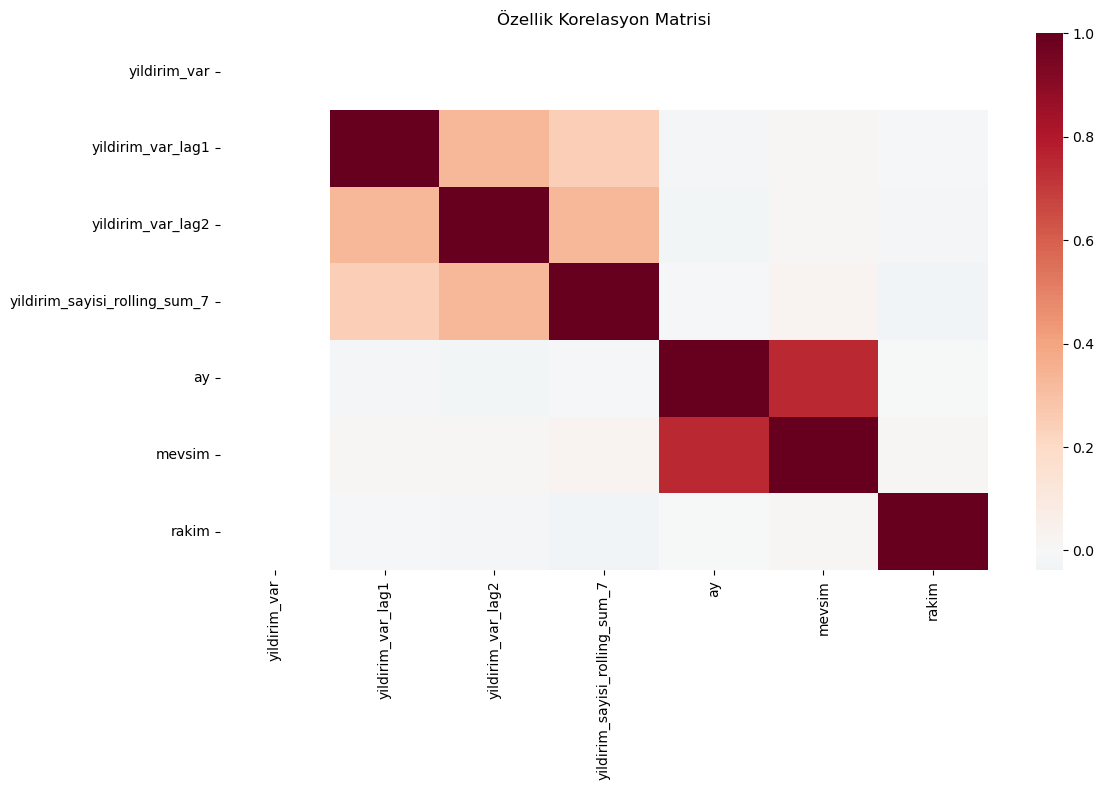

In [11]:
# Korelasyon görselleştirmesi
fig, ax = plt.subplots(figsize=(12, 8))

# En önemli özellikleri seç
onemli_ozellikler = ['yildirim_var', 'yildirim_var_lag1', 'yildirim_var_lag2', 
                     'yildirim_sayisi_rolling_sum_7', 'ay', 'mevsim', 'rakim']
mevcut_ozellikler = [f for f in onemli_ozellikler if f in ana_df_temiz.columns]

if len(mevcut_ozellikler) > 1:
    kor_matris = ana_df_temiz[mevcut_ozellikler].corr()
    sns.heatmap(kor_matris, annot=True, cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Özellik Korelasyon Matrisi')
    plt.tight_layout()
    plt.savefig('../tez_docs/figures/korelasyon_matrisi.png', dpi=150)
    plt.show()

## 3.8 Verilerin Kaydedilmesi

In [12]:
# Model için hazır veri setini kaydet
ana_df_temiz.to_pickle(DATA_PATH + 'model_veri_seti.pkl')

print("Model için hazır veri seti kaydedildi!")
print(f"Boyut: {ana_df_temiz.shape}")

Model için hazır veri seti kaydedildi!
Boyut: (3286, 37)


In [13]:
# Özellik listesi
hedef = 'yildirim_var'
cikartilacaklar = ['tarih', 'yildirim_sayisi', 'yildirim_var', 'ort_akim', 'maks_akim', 'min_akim', 'ort_mesafe']
ozellikler = [col for col in ana_df_temiz.columns if col not in cikartilacaklar]

print(f"\nHedef değişken: {hedef}")
print(f"Özellik sayısı: {len(ozellikler)}")
print(f"\nÖzellikler:")
for i, f in enumerate(ozellikler, 1):
    print(f"  {i}. {f}")

# Özellik listesini kaydet
import json
with open(DATA_PATH + 'ozellik_listesi.json', 'w', encoding='utf-8') as f:
    json.dump({'hedef': hedef, 'ozellikler': ozellikler}, f, ensure_ascii=False, indent=2)


Hedef değişken: yildirim_var
Özellik sayısı: 30

Özellikler:
  1. istasyon_no
  2. yil
  3. ay
  4. gun
  5. haftanin_gunu
  6. yilin_gunu
  7. mevsim
  8. enlem
  9. boylam
  10. rakim
  11. yildirim_sayisi_lag1
  12. yildirim_sayisi_lag2
  13. yildirim_sayisi_lag3
  14. yildirim_sayisi_lag7
  15. yildirim_var_lag1
  16. yildirim_var_lag2
  17. yildirim_var_lag3
  18. yildirim_var_lag7
  19. yildirim_sayisi_rolling_mean_3
  20. yildirim_sayisi_rolling_sum_3
  21. yildirim_sayisi_rolling_mean_7
  22. yildirim_sayisi_rolling_sum_7
  23. yildirim_sayisi_rolling_mean_14
  24. yildirim_sayisi_rolling_sum_14
  25. ay_sin
  26. ay_cos
  27. gun_sin
  28. gun_cos
  29. hafta_sin
  30. hafta_cos


---
**Sonraki Adım:** `04_model_egitimi.ipynb` - Model Eğitimi